In [13]:
# 한글 폰트 설정 (윈도우용)
import matplotlib.font_manager as font_manager
font_path = "C:/Windows/Fonts/malgun.ttf"  # 'Malgun Gothic' 폰트 경로
font_prop = font_manager.FontProperties(fname=font_path)

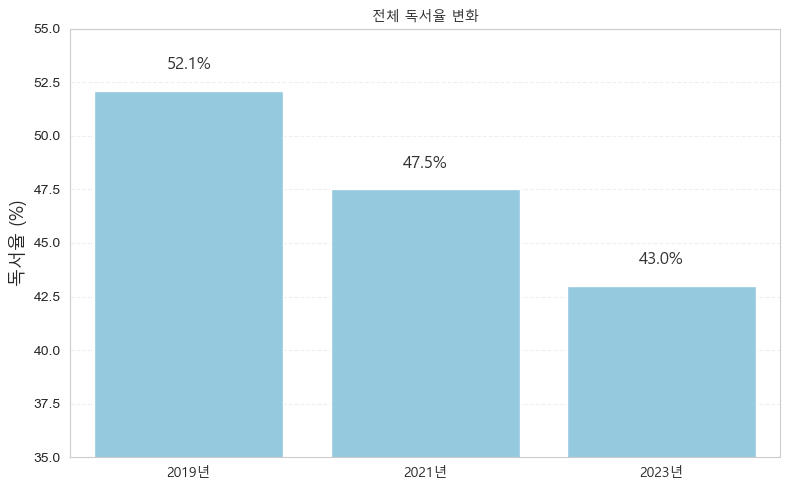

In [191]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import matplotlib as mpl
import warnings

# ⚠️ 경고 무시
warnings.filterwarnings("ignore", category=UserWarning)

# ✅ 한글 폰트 설정
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = fm.FontProperties(fname=font_path).get_name()
font_prop = fm.FontProperties(fname=font_path)

plt.rc('font', family=font_name)
mpl.rcParams['axes.unicode_minus'] = False

# 📄 데이터 불러오기
df = pd.read_csv("독서율_비교_2019vs2021vs2023.csv")

# 전처리
df_melted = df.melt(id_vars='구분(독서율 %)', var_name='년도', value_name='독서율(%)')
df_total = df_melted[df_melted['구분(독서율 %)'] == '전체'].copy()

# 📊 세로 막대그래프 시각화
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

sns.barplot(
    data=df_total,
    x='년도',
    y='독서율(%)',
    color='skyblue'
)

# 수치 표시
for index, row in df_total.iterrows():
    plt.text(row['년도'], row['독서율(%)'] + 1,
             f"{row['독서율(%)']:.1f}%",
             ha='center',  # ← 중앙 정렬!
             fontsize=12, fontproperties=font_prop, color='#333333')

# 🏷️ 제목 및 축
plt.title('전체 독서율 변화', fontsize=17, weight='bold', fontproperties=font_prop)
plt.ylabel('독서율 (%)', fontsize=13, fontproperties=font_prop)
plt.xlabel('', fontsize=13)
plt.xticks(fontproperties=font_prop)

plt.ylim(35, 55)
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

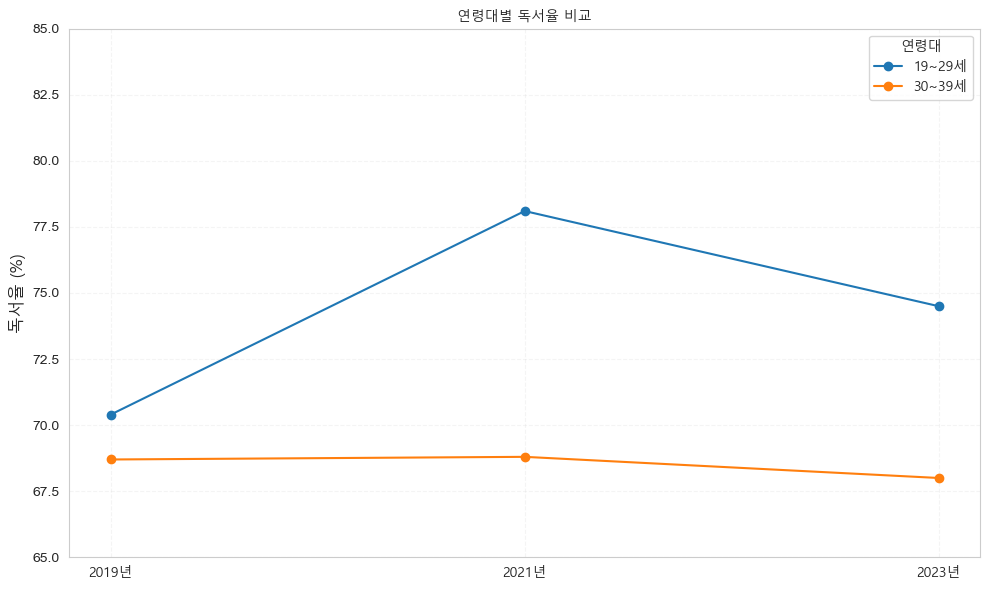

In [169]:
df_melted = df.melt(id_vars='구분(독서율 %)', var_name='년도', value_name='독서율(%)')

# 포함할 연령대 목록
target_ages = ['19~29세', '30~39세']


# 시각화 재실행
plt.figure(figsize=(10, 6))
for age_group in target_ages:
    group_data = df_melted[df_melted['구분(독서율 %)'] == age_group]
    plt.plot(group_data['년도'], group_data['독서율(%)'], marker='o', label=age_group)
    
plt.title('연령대별 독서율 비교', fontsize=16, weight='bold', fontproperties=font_prop)
plt.xlabel('')
plt.ylabel('독서율 (%)', fontsize=12, fontproperties=font_prop)
plt.xticks(fontproperties=font_prop)
plt.legend(title='연령대', title_fontproperties=font_prop, prop=font_prop)
plt.grid(True, linestyle='--', alpha=0.2)
plt.ylim(65, 85)

plt.tight_layout()
plt.show()